In [1]:
SEED = 42

import math
import numpy as np
import jax
import jax.numpy as jnp

import optax

rng = jax.random.PRNGKey(SEED)

import torchvision

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
data_train = torchvision.datasets.MNIST(root='data/', train=True, download=True)
data_test = torchvision.datasets.MNIST(root='data/', train=False, download=True)

X_train, y_train = data_train.data.numpy(), data_train.targets.numpy()
X_test, y_test = data_test.data.numpy(), data_test.targets.numpy()

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [3]:
_, width, height = X_train.shape

In [4]:
@jax.jit
def mlp(x, parameters):
    *body, head = parameters
    result = x.reshape((-1, width * height))
    for W, b in body:
        result = jax.nn.sigmoid(result @ W + b)

    W, b = head
    return result @ W + b

def init_mlp(key, units):
    parameters = list()

    for n_in, n_out in zip(units[:-1], units[1:]):
        key, key_W = jax.random.split(key, num=2)
        W = jax.random.normal(key_W, shape=(n_in, n_out)) / math.sqrt(n_in)
        b = jnp.zeros(shape=(n_out, ))

        parameters.append((W, b))
    return parameters

In [5]:
optimizer = optax.adamw(learning_rate=1.0e-3)

In [6]:
@jax.jit
def loss_fn(x, y, parameters):
    y_one_hot = jax.nn.one_hot(y, 10, dtype=jnp.float32)
    predictions = mlp(x, parameters)

    logits = jax.nn.log_softmax(predictions, axis=1)
    loss = -jnp.sum(logits * y_one_hot, axis=1)
    return jnp.mean(loss)

@jax.jit
def step(x, y, parameters, state):
    loss, grad = jax.value_and_grad(loss_fn, argnums=2)(x, y, parameters)
    updates, state_updated = optimizer.update(grad, state, parameters)
    parameters_updated = optax.apply_updates(parameters, updates)

    return loss, parameters_updated, state_updated

In [7]:
n_epochs = 9
batch_size = 32
n_iterations = X_train.shape[0] // batch_size

losses = np.ndarray(shape=(n_epochs, n_iterations))

rng, key_init = jax.random.split(rng, num=2)
parameters = init_mlp(key_init, units=(width * height, 16, 10))

state = optimizer.init(parameters)

for i in tqdm(range(n_epochs)):
    for j in tqdm(range(n_iterations), leave=False):
        rng, key_index = jax.random.split(rng, num=2)
        index = jax.random.randint(key_index, minval=0, maxval=X_train.shape[0], shape=(batch_size, ))

        losses[i, j], parameters, state = step(X_train[index], y_train[index], parameters, state)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

In [8]:
def plot_losses(losses, n_bands=4):
    epochs = np.arange(losses.shape[0])
    bands = np.quantile(losses, q=np.linspace(0, 1, num=2 * n_bands + 3)[1:-1], axis=1)
    
    fig = plt.figure(figsize=(9, 6))
    axes = fig.subplots(1, 1)
    
    for i in range(n_bands):
        axes.fill_between(epochs, bands[i], bands[-i - 1], alpha=0.2, color=plt.cm.tab10(0))
    
    axes.plot(epochs, bands[n_bands])

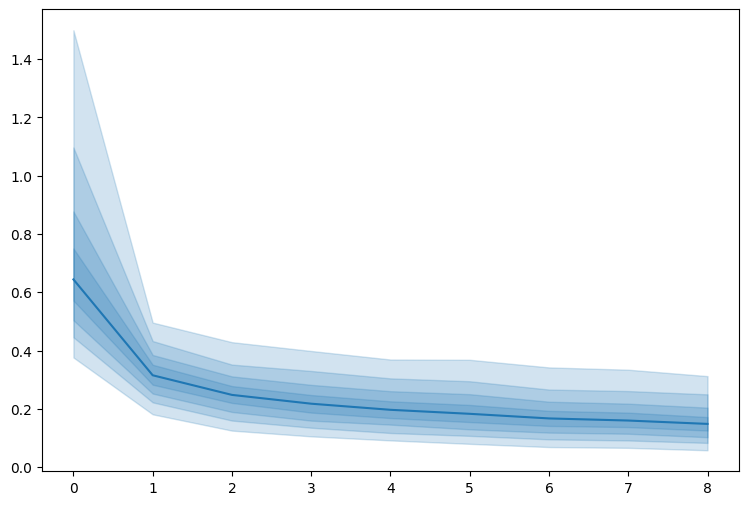

In [9]:
plot_losses(losses)

In [10]:
predictions = mlp(X_test, parameters)
accuracy = np.mean(jnp.argmax(predictions, axis=1) == y_test)
print(accuracy)

0.94259995


In [11]:
(W, _), *_ = parameters

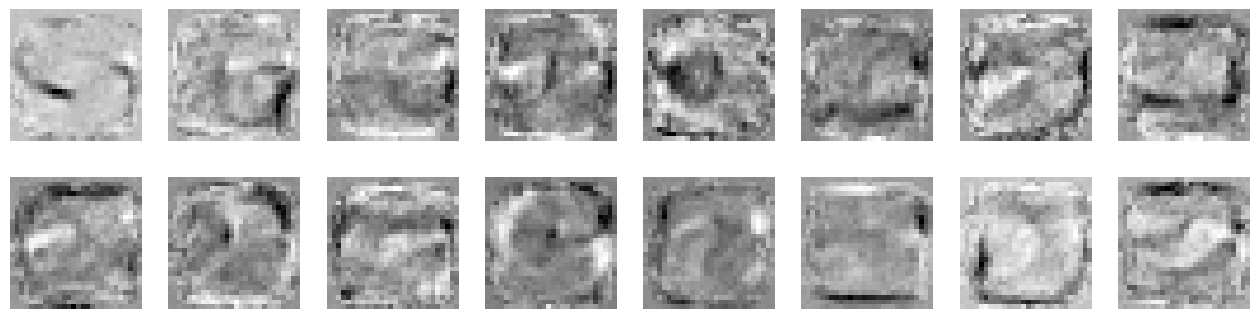

In [12]:
fig = plt.figure(figsize=(16, 4))
axes = fig.subplots(2, 8, squeeze=False).ravel()

for i in range(W.shape[1]):
    axes[i].imshow(W[:, i].reshape((width, height)), cmap=plt.cm.Grays)
    axes[i].axis('off')